# Import


In [15]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
!pip install mlflow


  Using cached mlflow-2.14.1-py3-none-any.whl (25.8 MB)
  Using cached SQLAlchemy-2.0.31-cp310-cp310-win_amd64.whl (2.1 MB)
  Using cached sqlparse-0.5.0-py3-none-any.whl (43 kB)
  Using cached alembic-1.13.1-py3-none-any.whl (233 kB)
  Using cached docker-7.1.0-py3-none-any.whl (147 kB)
  Using cached cloudpickle-3.0.0-py3-none-any.whl (20 kB)
  Using cached waitress-3.0.0-py3-none-any.whl (56 kB)
  Using cached querystring_parser-1.2.4-py2.py3-none-any.whl (7.9 kB)
  Using cached opentelemetry_sdk-1.25.0-py3-none-any.whl (107 kB)
  Using cached flask-3.0.3-py3-none-any.whl (101 kB)
  Using cached opentelemetry_api-1.25.0-py3-none-any.whl (59 kB)
  Using cached graphene-3.3-py2.py3-none-any.whl (128 kB)
  Using cached Mako-1.3.5-py3-none-any.whl (78 kB)
  Using cached click-8.1.7-py3-none-any.whl (97 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
  Using cached werkzeug-3.0.3-py3-none-any.whl (227 kB)
  Using cached aniso8601-9.0.1-py2.py3-none-any.whl (52 kB)
  Using 

In [16]:
# Import
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset
from typing import Union, List, Tuple
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import os
import mlflow
import mlflow.pytorch
from datetime import datetime
from matplotlib.colors import ListedColormap


# MLflow run

In [17]:
# Start an MLflow run
mlflow.start_run(run_name=f"inference-{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


<ActiveRun: >

# Setup



In [18]:

# Définition du modèle
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(1, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 256)
        self.up1 = Up(512, 128, bilinear)
        self.up2 = Up(256, 64, bilinear)
        self.up3 = Up(128, 32, bilinear)
        self.up4 = Up(64, 32, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# Load model


In [19]:

# Chargement du modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "C:/Users/n.vanderesse/Desktop/STAGE_Nolan/Git/IA-SeReOs/RDN.pth"
net = UNet_Light_RDN(n_channels=1, n_classes=3)
net.load_state_dict(torch.load(model_path, map_location=device))
net.to(device)
net.eval()

# Vérifiez si le fichier du modèle existe
if not os.path.exists(model_path):
    print(f"Model file not found at {model_path}")
else:
    net = UNet_Light_RDN(n_channels=1, n_classes=3)
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.to(device)
    net.eval()
    print("Model loaded successfully.")
    mlflow.pytorch.log_model(net, "model")

# Log parameters
mlflow.log_param("model_path", model_path)

# Fonction pour charger une image sans prétraitement
def load_image(image_path):
    image = Image.open(image_path).convert('L')  # Convertir en niveaux de gris
    transform = transforms.ToTensor()  # Convertir en tenseur sans redimensionnement ni normalisation
    return transform(image).unsqueeze(0).to(device)  # Ajouter une dimension de lot


Model loaded successfully.


# Inference

In [20]:
# Inference function with argmax 
def run_inference(image_path):
    input_tensor = load_image(image_path)
    print(f"Input tensor shape: {input_tensor.shape}, dtype: {input_tensor.dtype}")  # Debugging line
    with torch.no_grad():
        output = net(input_tensor)
        print(f"Model output shape: {output.shape}, dtype: {output.dtype}")  # Debugging line
        pred = torch.argmax(output, dim=1).cpu().numpy()
    print(f"Prediction shape: {pred.shape}, unique values: {np.unique(pred)}")  # Debugging line    # cpu to use numpy and numpy for easier handling    # argmax to identify the class for each pixel in the image
    return pred[0]  # Remove batch dimension

# Visualization

In [21]:

# Fonction de visualisation
def visualize_results(image_path, prediction):
    image = Image.open(image_path).convert('L')
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image, cmap='gray')   # display in grayscale 
    ax[0].set_title('Input Image')
    
    # Map each class to its corresponding grayscale intensity
    grayscale_map = {
        2: 255,  # Bone (white)
        1: 128,  # Dirt (gray)
        0: 0     # Air (black)
    }
    
    # Apply the grayscale map to the prediction
    segmented_image = np.zeros_like(prediction, dtype=np.uint8)
    for class_value, grayscale_value in grayscale_map.items():
        segmented_image[prediction == class_value] = grayscale_value

    ax[1].imshow(segmented_image, cmap='gray')
    ax[1].set_title('Predicted Mask')
    
    for a in ax:
        a.axis('off') # remove axis for more clarity
    plt.show()
    
    # Log segmented image as artifact
    plt.imsave('segmented_image.png', segmented_image, cmap='gray')
    mlflow.log_artifact('segmented_image.png')


# Application

Input tensor shape: torch.Size([1, 1, 1236, 1533]), dtype: torch.float32
Model output shape: torch.Size([1, 3, 1236, 1533]), dtype: torch.float32
Prediction shape: (1, 1236, 1533), unique values: [0 1 2]


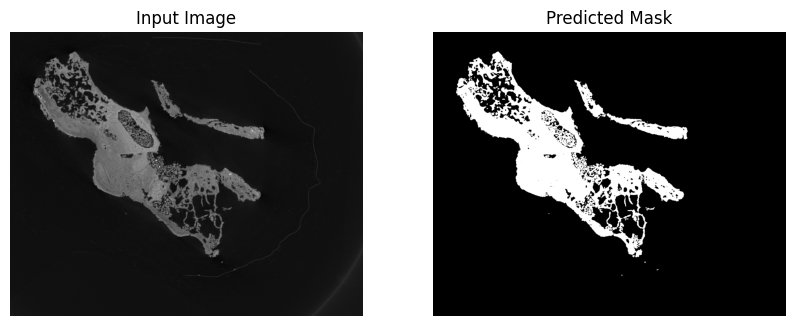

In [22]:

# Application
image_path = "D:/Donnees_pour_segmentation_RDN/data/Nicolas/dataset/unseg/EL_BARGA_Lot_2_Merged_Scans_1-32722.tif"
mlflow.log_param("image_path", image_path)
prediction = run_inference(image_path)
visualize_results(image_path, prediction)


# End the MLflow run
mlflow.end_run()